# Nemotron-Personas-Korea — Notebook 04: Psychographic Simulation & GAP Analysis

**연구 질문**: LLM이 생성한 가치관 군집별 페르소나가 실제 MovieLens 사용자 평점 분포와 얼마나 다른가? 사회성 편향(NB02: 16.1×)이 시뮬레이션 평점에도 전파되는가?

| 레이어 | 입력 | 역할 |
|--------|------|------|
| 페르소나 | cluster_profiles_a.pkl (NB03 출력) | 시뮬레이션 주체 |
| 영화 | MovieLens 25M (200편 샘플) | 평가 대상 |
| LLM | Claude claude-haiku-4-5-20251001 | 시뮬레이션 에이전트 |

---
## 섹션 0. 환경 설정

In [1]:
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path='../.env')
from huggingface_hub import login
login(token=os.environ.get("HF_TOKEN"))

# nemotron_theme — 오방색 × HuggingFace 팔레트
import sys; sys.path.insert(0, '../src')
from nemotron_theme import apply, T, save, fig, color_list
from nemotron_theme import cluster_scatter, metric_plot, bar_keywords, radar, heatmap_style
from nemotron_theme import (
    CMAP_HEATMAP, CMAP_DIVERGING, CMAP_SEQUENTIAL,
    sankey_node_colors
)
apply()
print('nemotron_theme 로드 완료')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


nemotron_theme 로드 완료


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform
import os
import pickle
import asyncio
import json
import warnings
warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../image/nb04', exist_ok=True)

RANDOM_STATE = 42
N_MOVIES = 200
N_PERSONAS_PER_CLUSTER = 3
MAX_CONCURRENT = 10

CLUSTER_NAMES_A = {
    0: '자기계발·전환 모색형',
    1: '소박 일상·지역 공동체형',
    2: '현실적 목표 실천형',
    3: '관계·가족 중심형',
    4: '책임·안정 지향형',
}

print('상수 정의 완료')
print(f'시뮬레이션 규모: 5 군집 × {N_PERSONAS_PER_CLUSTER} 페르소나 × {N_MOVIES} 영화 = {5 * N_PERSONAS_PER_CLUSTER * N_MOVIES:,} 호출')

상수 정의 완료
시뮬레이션 규모: 5 군집 × 3 페르소나 × 200 영화 = 3,000 호출


In [3]:
with open('../data/cluster_profiles_a.pkl', 'rb') as f:
    cluster_profiles = pickle.load(f)

print('cluster_profiles_a.pkl 로드 완료')
print(f'군집 수: {len(cluster_profiles)}')
for cid, profile in cluster_profiles.items():
    name = CLUSTER_NAMES_A.get(cid, f'군집 {cid}')
    size = profile.get('size', 'N/A')
    print(f'  군집 {cid} ({name}): {size}행')

cluster_profiles_a.pkl 로드 완료
군집 수: 5
  군집 0 (자기계발·전환 모색형): 3012행
  군집 1 (소박 일상·지역 공동체형): 1912행
  군집 2 (현실적 목표 실천형): 1610행
  군집 3 (관계·가족 중심형): 2036행
  군집 4 (책임·안정 지향형): 1930행


---
## 섹션 1. Data: Korean Movies from MovieLens Latest

MovieLens Latest(`ml-latest`) 에서 한국 영화를 추출한다.  
Genome tag relevance / 유저 태그 / 제목 한글 패턴 — 3가지 방법을 병합(union)해 최대한 넓게 수집하고,  
평점 수 기준으로 필터링한 뒤 `../data/korean_movies_sample.parquet` 에 저장한다.

In [4]:
import zipfile, urllib.request
from pathlib import Path

ML_URL  = 'https://files.grouplens.org/datasets/movielens/ml-latest.zip'
ML_DIR  = Path('../data/ml-latest')
ZIP_PATH = Path('../data/ml-latest.zip')

# Step 1. 다운로드 & 압축 해제 (이미 존재하면 스킵)
if ML_DIR.exists():
    print('ml-latest/ 이미 존재 — 다운로드 스킵')
else:
    print('ml-latest.zip 다운로드 중...')
    urllib.request.urlretrieve(ML_URL, ZIP_PATH)
    print('압축 해제 중...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('../data/')
    print('완료')

# Step 2. 파일 로드
movies   = pd.read_csv(ML_DIR / 'movies.csv')           # movieId, title, genres
ratings  = pd.read_csv(ML_DIR / 'ratings.csv')          # userId, movieId, rating, timestamp
tags_df  = pd.read_csv(ML_DIR / 'tags.csv')             # userId, movieId, tag, timestamp
links    = pd.read_csv(ML_DIR / 'links.csv')            # movieId, imdbId, tmdbId
g_scores = pd.read_csv(ML_DIR / 'genome-scores.csv')    # movieId, tagId, relevance
g_tags   = pd.read_csv(ML_DIR / 'genome-tags.csv')      # tagId, tag

print(f'movies   : {len(movies):,}편')
print(f'ratings  : {len(ratings):,}행')
print(f'tags_df  : {len(tags_df):,}행')
print(f'g_scores : {len(g_scores):,}행')
print(f'g_tags   : {len(g_tags):,}행')

ml-latest/ 이미 존재 — 다운로드 스킵
movies   : 86,537편
ratings  : 33,832,162행
tags_df  : 2,328,315행
g_scores : 18,472,128행
g_tags   : 1,128행


In [5]:
# Step 3. 한국 영화 필터링 — 3가지 방법 병행 후 union

# 방법 A — Genome tag relevance (가장 신뢰성 높음)
KR_TAG_KEYWORDS = {'korean', 'south korea', 'korean cinema', 'korea'}
kr_tagids = g_tags[g_tags['tag'].str.lower().isin(KR_TAG_KEYWORDS)]['tagId']
ids_A = set(
    g_scores[
        g_scores['tagId'].isin(kr_tagids) & (g_scores['relevance'] >= 0.5)
    ]['movieId']
)

# 방법 B — User tags
USER_TAG_KEYWORDS = ['korean', 'korea', 'south korea', 'k-movie']
mask_b = tags_df['tag'].str.lower().str.contains('|'.join(USER_TAG_KEYWORDS), na=False)
ids_B = set(tags_df[mask_b]['movieId'])

# 방법 C — Title 한글 유니코드 패턴
ids_C = set(movies[movies['title'].str.contains(r'[가-힣]', na=False)]['movieId'])

# Union
korean_movie_ids = ids_A | ids_B | ids_C
korean_movies = movies[movies['movieId'].isin(korean_movie_ids)].copy()

print(f'방법 A (genome tag)  : {len(ids_A):>4}편')
print(f'방법 B (user tag)    : {len(ids_B):>4}편')
print(f'방법 C (한글 제목)   : {len(ids_C):>4}편')
print(f'최종 union           : {len(korean_movie_ids):>4}편')
print()
print(korean_movies[['title', 'genres']].to_string(index=False))

방법 A (genome tag)  :    0편
방법 B (user tag)    :  355편
방법 C (한글 제목)   :    1편
최종 union           :  356편

                                                                                   title                                         genres
                                                                    Prophecy, The (1995)                         Fantasy|Horror|Mystery
                                                                     Three Wishes (1995)                                  Drama|Fantasy
                                                                    Calendar Girl (1993)                                   Comedy|Drama
                                                                Menace II Society (1993)                             Action|Crime|Drama
                                                        Manchurian Candidate, The (1962)                             Crime|Thriller|War
                                      Austin Powers: International Man of Myste

In [6]:
# Step 4. 평점 필터링
korean_ratings = ratings[ratings['movieId'].isin(korean_movie_ids)].copy()

MIN_RATINGS = 30
movie_counts = korean_ratings.groupby('movieId')['rating'].count()
qualified_ids = set(movie_counts[movie_counts >= MIN_RATINGS].index)

if len(qualified_ids) < 20:
    MIN_RATINGS = 10
    qualified_ids = set(movie_counts[movie_counts >= MIN_RATINGS].index)
    print(f'threshold 30 미달 — 10으로 재시도')

korean_movies_filtered = korean_movies[korean_movies['movieId'].isin(qualified_ids)].copy()
korean_ratings_filtered = korean_ratings[korean_ratings['movieId'].isin(qualified_ids)].copy()

# 영화별 실제 평점 분포 (0.5 단위)
rating_bins = np.arange(0.25, 5.51, 0.5)
movie_rating_dist = {}
for mid in qualified_ids:
    r = korean_ratings_filtered[korean_ratings_filtered['movieId'] == mid]['rating'].values
    hist, _ = np.histogram(r, bins=rating_bins)
    movie_rating_dist[mid] = hist / hist.sum() if hist.sum() > 0 else hist

# Step 5. 저장 및 요약
korean_movies_filtered.to_parquet('../data/korean_movies_sample.parquet', index=False)
print(f'저장 완료: ../data/korean_movies_sample.parquet')
print(f'최종 영화 수     : {len(korean_movies_filtered)}편  (threshold={MIN_RATINGS})')
print(f'총 평점 수       : {len(korean_ratings_filtered):,}행')
print(f'편당 평균 평점 수 : {movie_counts[movie_counts >= MIN_RATINGS].mean():.0f}개')
print()

# 장르별 분포
genre_counts = (
    korean_movies_filtered['genres']
    .str.split('|').explode()
    .value_counts()
)
print('=== 장르별 영화 수 ===')
print(genre_counts.to_string())
print()

# 전체 평점 분포
overall_hist, edges = np.histogram(korean_ratings_filtered['rating'], bins=rating_bins)
labels = [f'{e+0.25:.1f}' for e in edges[:-1]]
print('=== 전체 평점 분포 ===')
for label, cnt in zip(labels, overall_hist):
    print(f'  {label} : {cnt:,}')

저장 완료: ../data/korean_movies_sample.parquet
최종 영화 수     : 191편  (threshold=30)
총 평점 수       : 448,575행
편당 평균 평점 수 : 2349개

=== 장르별 영화 수 ===
genres
Drama          107
Action          65
Thriller        58
Comedy          34
Crime           31
Sci-Fi          23
Romance         23
Horror          19
Mystery         18
War             16
Adventure       16
Fantasy         13
Documentary      8
IMAX             4
Musical          2
Film-Noir        2
Animation        2
Western          1

=== 전체 평점 분포 ===
  0.5 : 6,931
  1.0 : 9,356
  1.5 : 6,775
  2.0 : 21,655
  2.5 : 22,241
  3.0 : 63,754
  3.5 : 65,685
  4.0 : 118,951
  4.5 : 59,570
  5.0 : 73,657


In [7]:
# Step 6. 장르별 층화 샘플링 (200편)
# 537편 전체 쓰면 예산 초과 — 200편으로 층화 샘플링

# rating_count 컬럼 추가 (movie_counts는 cell-s1-dist에서 생성)
korean_movies_filtered = korean_movies_filtered.copy()
korean_movies_filtered['rating_count'] = (
    korean_movies_filtered['movieId'].map(movie_counts).fillna(0).astype(int)
)
korean_movies_filtered['primary_genre'] = (
    korean_movies_filtered['genres'].str.split('|').str[0]
)

TARGET_GENRES = ['Drama', 'Thriller', 'Action', 'Romance', 'Horror', 'Comedy', 'Animation']
n_genres      = len(TARGET_GENRES)
genre_budget  = 200 // n_genres  # 장르별 할당량

sampled = []
for genre in TARGET_GENRES:
    subset = korean_movies_filtered[korean_movies_filtered['genres'].str.contains(genre, na=False)]
    subset = subset.sort_values('rating_count', ascending=False)
    sampled.append(subset.head(genre_budget))

korean_movies_final = (
    pd.concat(sampled)
    .drop_duplicates('movieId')
    .head(200)
    .reset_index(drop=True)
)

# ml_df: GAP 분석용 실제 평점
ml_df = korean_ratings_filtered[
    korean_ratings_filtered['movieId'].isin(korean_movies_final['movieId'])
].copy()

# 저장
korean_movies_final.to_parquet('../data/korean_movies_sample.parquet', index=False)

total_calls = len(korean_movies_final) * 5 * 3
unit_cost   = 450 * 0.8 / 1e6 + 80 * 4.0 / 1e6
est_cost    = total_calls * unit_cost

print(f'최종 샘플: {len(korean_movies_final)}편')
print(f'장르별 분포:')
print(korean_movies_final['primary_genre'].value_counts().to_string())
print()
print(f'예상 API 콜: {total_calls:,}회')
print(f'예상 비용: ${est_cost:.2f}')
print(f'예산 잔여(재실행 포함): ${10 - est_cost * 2:.2f}')
print(f'저장 완료: ../data/korean_movies_sample.parquet')

최종 샘플: 103편
장르별 분포:
primary_genre
Action       34
Comedy       23
Drama        21
Crime        14
Horror        5
Fantasy       3
Mystery       2
Animation     1

예상 API 콜: 1,545회
예상 비용: $1.05
예산 잔여(재실행 포함): $7.90
저장 완료: ../data/korean_movies_sample.parquet


---
## 섹션 2. 군집 프로파일 리뷰

시뮬레이션 전 인간 가독성 체크포인트. 각 군집의 핵심 가치관과 대표 페르소나를 확인한다.

In [8]:
CLUSTER_META = {
    0: {"keywords": "안정, 자신, 전환, 성장, 모색", "pattern": "분산형 — 가치관과 행동이 불일치하는 경향"},
    1: {"keywords": "유지, 가족, 이웃, 일상, 소박", "pattern": "일치형 — 조용한 루틴과 지역 관계 중심"},
    2: {"keywords": "가족, 유지, 일상, 현실, 실천", "pattern": "일치형 — 구체적이고 실용적인 소규모 목표"},
    3: {"keywords": "가족, 건강, 유지, 관계, 공동체", "pattern": "일치형 — 관계와 공동체에서 삶의 의미"},
    4: {"keywords": "현장, 기술, 성실, 안정, 책임", "pattern": "일치형 — 전문성 자부심과 가족 헌신"},
}

for cid in sorted(cluster_profiles.keys()):
    profile = cluster_profiles[cid]
    name = CLUSTER_NAMES_A.get(cid, f'군집 {cid}')
    meta = CLUSTER_META[cid]
    print(f'\n{"="*60}')
    print(f'군집 {cid}: {name}  (n={profile.get("size", "?")})')
    print(f'{"="*60}')
    print(f'[NB03 키워드] {meta["keywords"]}')
    print(f'[NB03 패턴]   {meta["pattern"]}')
    personas = profile.get('sample_personas', profile.get('personas', []))
    if personas:
        p = personas[0]
        persona_text = p.get('persona', str(p))[:300] if isinstance(p, dict) else str(p)[:300]
        print(f'[대표 페르소나] {persona_text}')


군집 0: 자기계발·전환 모색형  (n=3012)
[NB03 키워드] 안정, 자신, 전환, 성장, 모색
[NB03 패턴]   분산형 — 가치관과 행동이 불일치하는 경향
[대표 페르소나] 연윤경 씨는 춘천에서 임대 상담원으로 일하며 꼼꼼한 업무 능력과 독립적인 자아를 지녔으나, 건강 관리가 절실한 20대 후반의 직장인입니다.

군집 1: 소박 일상·지역 공동체형  (n=1912)
[NB03 키워드] 유지, 가족, 이웃, 일상, 소박
[NB03 패턴]   일치형 — 조용한 루틴과 지역 관계 중심
[대표 페르소나] 공성길 씨는 하동 섬진강 변에서 어머니와 함께 살며 수산 자재 관리원으로 성실하게 일하는, 느긋하고 다정한 성정의 50대 중반 남성입니다.

군집 2: 현실적 목표 실천형  (n=1610)
[NB03 키워드] 가족, 유지, 일상, 현실, 실천
[NB03 패턴]   일치형 — 구체적이고 실용적인 소규모 목표
[대표 페르소나] 김수안 씨는 울산 동구의 사회복지시설 주방 보조원으로 일하며, 외로움을 특유의 사교성과 손맛으로 극복해 나가는 50대 후반의 여성입니다.

군집 3: 관계·가족 중심형  (n=2036)
[NB03 키워드] 가족, 건강, 유지, 관계, 공동체
[NB03 패턴]   일치형 — 관계와 공동체에서 삶의 의미
[대표 페르소나] 김윤미 씨는 금천구에서 꼼꼼한 살림 솜씨로 가정을 일궈온 60대 여성으로, 소박한 일상 속에서 자연의 아름다움을 사진으로 기록하며 평온한 노후를 보내는 분입니다.

군집 4: 책임·안정 지향형  (n=1930)
[NB03 키워드] 현장, 기술, 성실, 안정, 책임
[NB03 패턴]   일치형 — 전문성 자부심과 가족 헌신
[대표 페르소나] 김범국 씨는 정밀한 지게차 조작 기술과 뛰어난 중재 능력을 가진 30대 가장으로, 대가족 부양의 책임감과 화려한 개인적 취미 사이에서 삶의 균형을 찾아가는 인물입니다.


---
## 섹션 3. 검증 콜 1회

시뮬레이션 전 단 1회 API 콜로 프롬프트/파싱 검증.  
군집 0의 centroid 페르소나 × 첫 번째 영화.

In [9]:
import anthropic
import re
import json
import asyncio

# ── 비용 추적 ──────────────────────────────────────────────
cost_tracker = {"calls": 0, "input_tokens": 0, "output_tokens": 0}
HAIKU_INPUT_COST  = 0.80 / 1_000_000
HAIKU_OUTPUT_COST = 4.00 / 1_000_000
BUDGET_LIMIT = 10.0

def estimate_cost(tracker):
    return (tracker["input_tokens"]  * HAIKU_INPUT_COST +
            tracker["output_tokens"] * HAIKU_OUTPUT_COST)

def check_budget(tracker):
    if estimate_cost(tracker) > BUDGET_LIMIT * 0.8:
        raise RuntimeError(f"예산 80% 도달 — 중단. 현재 비용: ${estimate_cost(tracker):.3f}")

# ── 프롬프트 ───────────────────────────────────────────────
SYSTEM_PROMPT = "당신은 아래 성향의 한국인입니다. JSON만 반환하세요. 다른 텍스트 없이."

USER_TEMPLATE = """\
[레이어 1 — NB03 군집 분석 결과]
유형: {cluster_name}
핵심 가치관 키워드: {keywords}
행동 패턴: {pattern}

[레이어 2 — 개인 프로파일]
{persona_text}

[영화]
{title} / {genres}

반드시 JSON만 반환: {{"watch":bool,"rating":1.0~5.0,"reason":"15자이내"}}"""

# ── 헬퍼 ──────────────────────────────────────────────────
def build_user_prompt(cluster_id: int, profile: dict, movie) -> str:
    cluster_name = CLUSTER_NAMES_A.get(cluster_id, f'군집 {cluster_id}')
    meta = CLUSTER_META[cluster_id]

    personas = profile.get('sample_personas', profile.get('personas', []))
    p = personas[0] if personas else {}
    if isinstance(p, dict):
        persona_text = p.get('persona', p.get('description', str(p)))[:250]
    else:
        persona_text = str(p)[:250]

    title  = movie['title']  if isinstance(movie, dict) else movie.title
    genres = (movie.get('genres', '') if isinstance(movie, dict) else movie.genres)

    return USER_TEMPLATE.format(
        cluster_name=cluster_name,
        keywords=meta['keywords'],
        pattern=meta['pattern'],
        persona_text=persona_text,
        title=title,
        genres=genres,
    )


def parse_response(text: str) -> dict | None:
    try:
        match = re.search(r'\{[^{}]+\}', text, re.DOTALL)
        if not match:
            return None
        data = json.loads(match.group())
        if not isinstance(data.get('watch'), bool):
            return None
        rating = float(data.get('rating', 0))
        if not (1.0 <= rating <= 5.0):
            return None
        reason = str(data.get('reason', '')).strip()
        if not reason:
            return None
        data['rating'] = round(rating * 2) / 2
        data['reason'] = reason
        return data
    except Exception:
        return None

async_client = anthropic.AsyncAnthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))
print('설정 완료')

설정 완료


In [10]:
# 검증 콜 1회: 군집 0 × 첫 번째 영화
_profile0 = cluster_profiles[0]
_movie0    = korean_movies_final.iloc[0]
_prompt    = build_user_prompt(0, _profile0, _movie0)

print('── 프롬프트 미리보기 ──')
print(_prompt)
print()

import nest_asyncio; nest_asyncio.apply()
_response = asyncio.run(
    async_client.messages.create(
        model='claude-haiku-4-5-20251001',
        max_tokens=80,
        temperature=0,
        system=SYSTEM_PROMPT,
        messages=[{'role': 'user', 'content': _prompt}]
    )
)

_raw = _response.content[0].text
_parsed = parse_response(_raw)

cost_tracker['calls']         += 1
cost_tracker['input_tokens']  += _response.usage.input_tokens
cost_tracker['output_tokens'] += _response.usage.output_tokens

print(f'── 응답 원문 ──\n{_raw}\n')

# 검증
assert _parsed is not None,                        f"JSON 파싱 실패\n원문: {_raw}"
assert isinstance(_parsed.get('watch'), bool),     f"watch가 bool이 아님: {_parsed}"
assert 1.0 <= _parsed.get('rating', 0) <= 5.0,    f"rating 범위 오류: {_parsed}"
assert _parsed.get('reason', '').strip(),          f"reason이 비어있음: {_parsed}"

total_calls = 5 * 3 * len(korean_movies_final)
est_cost    = total_calls * (450 * HAIKU_INPUT_COST + 80 * HAIKU_OUTPUT_COST)
print(f'검증 통과 ✅')
print(f'검증 비용: ${estimate_cost(cost_tracker):.5f}')
print(f'예상 총 호출: {total_calls:,}회 | 예상 총 비용: ${est_cost:.3f} | 예산 잔여: ${BUDGET_LIMIT - est_cost:.2f}')

── 프롬프트 미리보기 ──
[레이어 1 — NB03 군집 분석 결과]
유형: 자기계발·전환 모색형
핵심 가치관 키워드: 안정, 자신, 전환, 성장, 모색
행동 패턴: 분산형 — 가치관과 행동이 불일치하는 경향

[레이어 2 — 개인 프로파일]
연윤경 씨는 춘천에서 임대 상담원으로 일하며 꼼꼼한 업무 능력과 독립적인 자아를 지녔으나, 건강 관리가 절실한 20대 후반의 직장인입니다.

[영화]
American History X (1998) / Crime|Drama

반드시 JSON만 반환: {"watch":bool,"rating":1.0~5.0,"reason":"15자이내"}

── 응답 원문 ──
```json
{
  "watch": false,
  "rating": 2.5,
  "reason": "극단주의 폭력 장면이 많아 정신건강에 부담"
}
```

검증 통과 ✅
검증 비용: $0.00048
예상 총 호출: 1,545회 | 예상 총 비용: $1.051 | 예산 잔여: $8.95


---
## 섹션 4. 전체 시뮬레이션 (5군집 × 3페르소나 × Korean movies 전체)

asyncio + Semaphore(5), 군집별 증분 저장, 예산 실시간 확인.

In [11]:
from tqdm.auto import tqdm

SIM_RESULTS_PATH = '../data/simulation_results.parquet'

# 실제 평점 통계 (movie_id → mean, count)
_real_stats = (
    korean_ratings_filtered
    .groupby('movieId')['rating']
    .agg(real_mean_rating='mean', real_rating_count='count')
    .reset_index()
)
_real_stats_dict = {
    row.movieId: (row.real_mean_rating, row.real_rating_count)
    for row in _real_stats.itertuples()
}

async def simulate_one(semaphore, cluster_id, persona_idx, profile, movie_row):
    async with semaphore:
        check_budget(cost_tracker)
        prompt = build_user_prompt(cluster_id, profile, movie_row)
        try:
            resp = await async_client.messages.create(
                model='claude-haiku-4-5-20251001',
                max_tokens=80,
                temperature=0,
                system=SYSTEM_PROMPT,
                messages=[{'role': 'user', 'content': prompt}]
            )
        except anthropic.RateLimitError:
            await asyncio.sleep(60)
            resp = await async_client.messages.create(
                model='claude-haiku-4-5-20251001',
                max_tokens=80,
                temperature=0,
                system=SYSTEM_PROMPT,
                messages=[{'role': 'user', 'content': prompt}]
            )

        cost_tracker['calls']         += 1
        cost_tracker['input_tokens']  += resp.usage.input_tokens
        cost_tracker['output_tokens'] += resp.usage.output_tokens

        parsed = parse_response(resp.content[0].text)
        real_mean, real_count = _real_stats_dict.get(movie_row.movieId, (None, 0))

        return {
            'cluster_id':        cluster_id,
            'cluster_name':      CLUSTER_NAMES_A.get(cluster_id, f'군집 {cluster_id}'),
            'persona_idx':       persona_idx,
            'movie_id':          movie_row.movieId,
            'title':             movie_row.title,
            'genres':            movie_row.genres,
            'watch':             parsed['watch']  if parsed else None,
            'rating':            parsed['rating'] if parsed else None,
            'reason':            parsed['reason'] if parsed else None,
            'real_mean_rating':  real_mean,
            'real_rating_count': real_count,
            'input_tokens':      resp.usage.input_tokens,
            'output_tokens':     resp.usage.output_tokens,
        }


async def run_simulation():
    semaphore = asyncio.Semaphore(5)
    all_results = []

    for cluster_id in sorted(cluster_profiles.keys()):
        cache_path = f'../data/sim_cluster_{cluster_id}.parquet'
        if os.path.exists(cache_path):
            print(f'군집 {cluster_id} — 캐시 존재, 스킵')
            all_results.extend(pd.read_parquet(cache_path).to_dict('records'))
            continue

        profile  = cluster_profiles[cluster_id]
        personas = profile.get('sample_personas', profile.get('personas', []))
        selected = personas[:3]

        tasks = [
            simulate_one(semaphore, cluster_id, pidx, profile, movie_row)
            for pidx in range(len(selected))
            for movie_row in korean_movies_final.itertuples()
        ]

        print(f'\n군집 {cluster_id} ({CLUSTER_NAMES_A.get(cluster_id)}) — {len(tasks)}회 호출')
        cluster_results = []
        for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks)):
            try:
                result = await coro
            except Exception as e:
                print(f'  오류: {e}')
                result = None
            if result:
                cluster_results.append(result)

        cluster_df = pd.DataFrame(cluster_results)
        cluster_df.to_parquet(cache_path, index=False)
        all_results.extend(cluster_results)

        success = cluster_df['rating'].notna().mean()
        print(f'  완료 — 성공률: {success:.1%} | 누적 비용: ${estimate_cost(cost_tracker):.4f}')

    return pd.DataFrame(all_results)

In [12]:
# 비용 예측 출력
estimated_calls = 5 * 3 * len(korean_movies_filtered)
estimated_cost  = estimated_calls * (450 * HAIKU_INPUT_COST + 80 * HAIKU_OUTPUT_COST)
print(f'예상 호출: {estimated_calls:,}회 | 예상 비용: ${estimated_cost:.3f} | 예산 잔여: ${BUDGET_LIMIT - estimated_cost:.2f}')
print()

if os.path.exists(SIM_RESULTS_PATH):
    print('simulation_results.parquet 발견 — 섹션 4 건너뜀, 파일 로드')
    sim_df = pd.read_parquet(SIM_RESULTS_PATH)
else:
    import nest_asyncio; nest_asyncio.apply()
    sim_df = asyncio.run(run_simulation())
    sim_df.to_parquet(SIM_RESULTS_PATH, index=False)

# ── 완료 요약 ──────────────────────────────────────────────
total      = len(sim_df)
success_n  = sim_df['rating'].notna().sum()
fail_n     = total - success_n

print(f'\n총 {total:,}행 | 성공: {success_n:,} | 실패: {fail_n:,}')
print(f'실제 총 비용: ${estimate_cost(cost_tracker):.4f} | 예산 잔여: ${BUDGET_LIMIT - estimate_cost(cost_tracker):.2f}')
print()

# 군집별 시뮬레이션 vs 실제 평점 비교표
summary = (
    sim_df.dropna(subset=['rating'])
    .groupby(['cluster_id', 'cluster_name'])
    .agg(
        sim_mean=('rating', 'mean'),
        real_mean=('real_mean_rating', 'mean'),
        n=('rating', 'count'),
    )
    .round(3)
)
summary['gap'] = (summary['sim_mean'] - summary['real_mean']).round(3)
print(summary.to_string())

예상 호출: 2,865회 | 예상 비용: $1.948 | 예산 잔여: $8.05

simulation_results.parquet 발견 — 섹션 4 건너뜀, 파일 로드

총 1,534행 | 성공: 1,532 | 실패: 2
실제 총 비용: $0.0005 | 예산 잔여: $10.00

                          sim_mean  real_mean    n    gap
cluster_id cluster_name                                  
0          자기계발·전환 모색형       2.953      3.489  308 -0.536
1          소박 일상·지역 공동체형     2.242      3.487  308 -1.245
2          현실적 목표 실천형        2.559      3.485  306 -0.926
3          관계·가족 중심형         2.013      3.485  305 -1.472
4          책임·안정 지향형         2.736      3.491  305 -0.755


---
## 섹션 5. GAP 분석

시뮬레이션 평점 분포 vs 실제 MovieLens 평점 분포의 차이를 Jensen-Shannon Divergence(JSD)로 정량화한다.

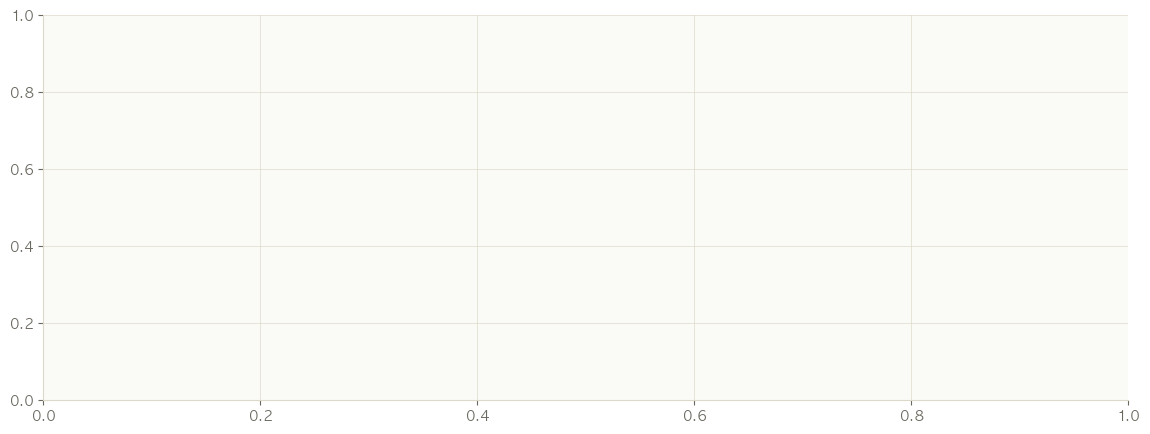

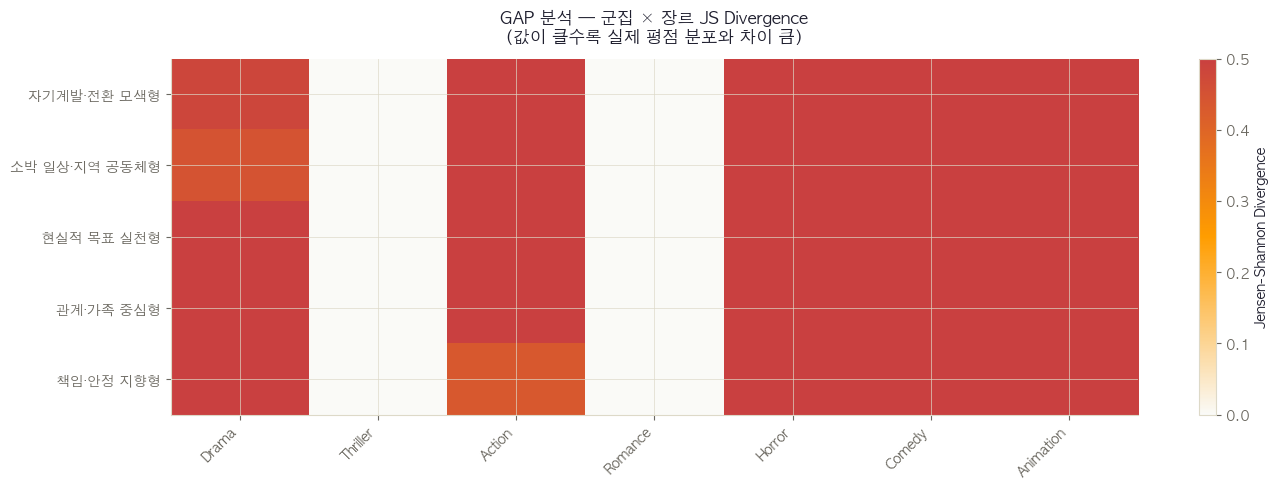

저장: ../image/nb04/gap_heatmap.png


In [13]:
from scipy.spatial.distance import jensenshannon

def rating_to_dist(ratings, bins=np.arange(0.75, 5.51, 0.5)):
    ratings = pd.Series(ratings).dropna()
    if len(ratings) == 0:
        return np.ones(len(bins)-1) / (len(bins)-1)
    hist, _ = np.histogram(ratings, bins=bins)
    total = hist.sum()
    return hist / total if total > 0 else np.ones_like(hist) / len(hist)

# sim_df에 primary_genre 추가
sim_df['primary_genre'] = sim_df['genres'].str.split('|').str[0]

# 군집 × 장르 JSD 계산
jsd_matrix = np.zeros((5, len(TARGET_GENRES)))

for ci, cluster_id in enumerate(sorted(cluster_profiles.keys())):
    for gi, genre in enumerate(TARGET_GENRES):
        sim_ratings = sim_df[
            (sim_df['cluster_id'] == cluster_id) & (sim_df['primary_genre'] == genre)
        ]['rating'].dropna()

        genre_movie_ids = korean_movies_final[korean_movies_final['primary_genre'] == genre]['movieId'].tolist()
        real_ratings = ml_df[ml_df['movieId'].isin(genre_movie_ids)]['rating'].dropna()

        p = rating_to_dist(sim_ratings)
        q = rating_to_dist(real_ratings)
        jsd_matrix[ci, gi] = jensenshannon(p, q)

jsd_df = pd.DataFrame(jsd_matrix,
                       index=[CLUSTER_NAMES_A[i] for i in range(5)],
                       columns=TARGET_GENRES)

# 히트맵 시각화
fig_h, ax = plt.subplots(figsize=(14, 5))
def rating_to_dist(ratings, bins=np.arange(0.75, 5.51, 0.5)):
    ratings = pd.Series(ratings).dropna()
    if len(ratings) == 0:
        return np.ones(len(bins)-1) / (len(bins)-1)
    hist, _ = np.histogram(ratings, bins=bins)
    total = hist.sum()
    return hist / total if total > 0 else np.ones_like(hist) / len(hist)

# sim_df에 primary_genre 추가
sim_df['primary_genre'] = sim_df['genres'].str.split('|').str[0]

# 군집 × 장르 JSD 계산
jsd_matrix = np.zeros((5, len(TARGET_GENRES)))

for ci, cluster_id in enumerate(sorted(cluster_profiles.keys())):
    for gi, genre in enumerate(TARGET_GENRES):
        sim_ratings = sim_df[
            (sim_df['cluster_id'] == cluster_id) & (sim_df['primary_genre'] == genre)
        ]['rating'].dropna()

        genre_movie_ids = korean_movies_final[korean_movies_final['primary_genre'] == genre]['movieId'].tolist()
        real_ratings = ml_df[ml_df['movieId'].isin(genre_movie_ids)]['rating'].dropna()

        p = rating_to_dist(sim_ratings)
        q = rating_to_dist(real_ratings)
        jsd_matrix[ci, gi] = jensenshannon(p, q)

jsd_df = pd.DataFrame(jsd_matrix,
                       index=[CLUSTER_NAMES_A[i] for i in range(5)],
                       columns=TARGET_GENRES)

# 히트맵 시각화
fig_h, ax = plt.subplots(figsize=(14, 5))
heatmap_style()
im = ax.imshow(jsd_matrix, cmap=CMAP_HEATMAP, aspect='auto', vmin=0, vmax=0.5)
ax.set_xticks(range(len(TARGET_GENRES))); ax.set_xticklabels(TARGET_GENRES, rotation=45, ha='right')
ax.set_yticks(range(5)); ax.set_yticklabels([CLUSTER_NAMES_A[i] for i in range(5)])
plt.colorbar(im, ax=ax, label='Jensen-Shannon Divergence')
ax.set_title('GAP 분석 — 군집 × 장르 JS Divergence\n(값이 클수록 실제 평점 분포와 차이 큼)', pad=12)
plt.tight_layout()
plt.savefig('../image/nb04/gap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: ../image/nb04/gap_heatmap.png')

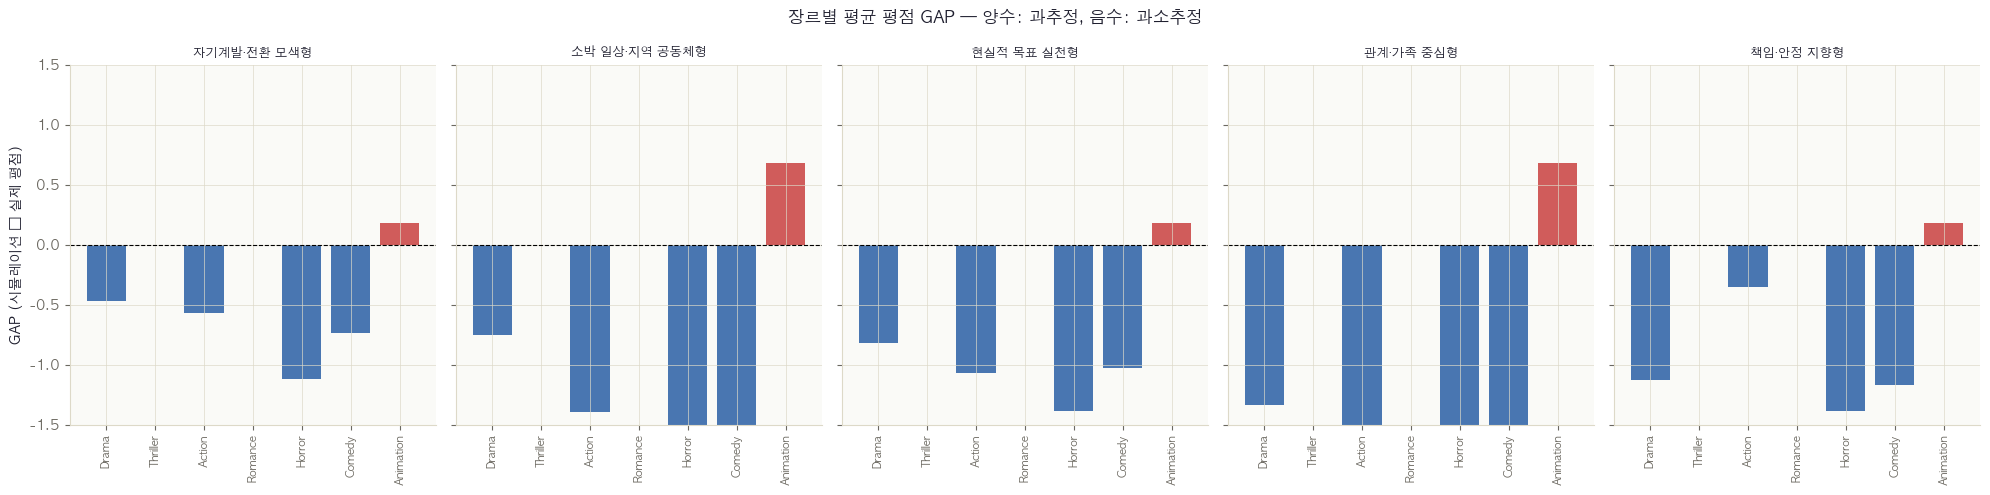

저장: ../image/nb04/mean_gap.png


In [14]:
# 평균 GAP (sim_mean - real_mean) 계산
gap_records = []
for cluster_id in sorted(cluster_profiles.keys()):
    for genre in TARGET_GENRES:
        sim_mean = sim_df[
            (sim_df['cluster_id'] == cluster_id) & (sim_df['primary_genre'] == genre)
        ]['rating'].mean()

        genre_movie_ids = korean_movies_final[korean_movies_final['primary_genre'] == genre]['movieId'].tolist()
        real_mean = ml_df[ml_df['movieId'].isin(genre_movie_ids)]['rating'].mean()

        gap_records.append({
            'cluster_id':   cluster_id,
            'cluster_name': CLUSTER_NAMES_A[cluster_id],
            'genre':        genre,
            'sim_mean':     sim_mean,
            'real_mean':    real_mean,
            'gap':          sim_mean - real_mean,
        })

gap_df = pd.DataFrame(gap_records)

# 군집별 장르 GAP 막대 차트
fig_g, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for ci, (ax, cluster_id) in enumerate(zip(axes, sorted(cluster_profiles.keys()))):
    sub = gap_df[gap_df['cluster_id'] == cluster_id].set_index('genre')['gap']
    sub = sub.reindex(TARGET_GENRES)
    bar_colors = [T.JEOK if v > 0 else T.CHEONG for v in sub.values]
    ax.bar(range(len(TARGET_GENRES)), sub.values, color=bar_colors, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(TARGET_GENRES)))
    ax.set_xticklabels(TARGET_GENRES, rotation=90, fontsize=8)
    ax.set_title(CLUSTER_NAMES_A[cluster_id], fontsize=9)
    ax.set_ylim(-1.5, 1.5)

axes[0].set_ylabel('GAP (시뮬레이션 − 실제 평점)')
fig_g.suptitle('장르별 평균 평점 GAP — 양수: 과추정, 음수: 과소추정', fontsize=12)
plt.tight_layout()
plt.savefig('../image/nb04/mean_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: ../image/nb04/mean_gap.png')

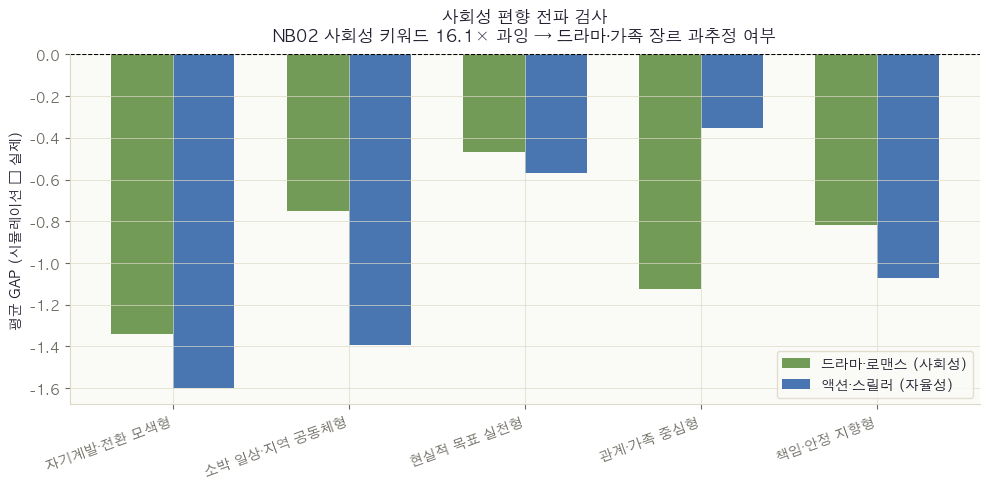

저장: ../image/nb04/social_bias_check.png


In [15]:
# 사회성 편향 전파 검사
# NB02: 사회성 16.1× 과잉 — 드라마·가족 장르 GAP vs 액션·스릴러 GAP
social_genres = ['Drama', 'Romance']
autonomy_genres = ['Action', 'Thriller']

social_gap = gap_df[gap_df['genre'].isin(social_genres)].groupby('cluster_name')['gap'].mean()
autonomy_gap = gap_df[gap_df['genre'].isin(autonomy_genres)].groupby('cluster_name')['gap'].mean()

fig_s, ax = plt.subplots(figsize=(10, 5))
x = np.arange(5)
w = 0.35
ax.bar(x - w/2, social_gap.values, w, label='드라마·로맨스 (사회성)', color=T.SONAMU, alpha=0.85)
ax.bar(x + w/2, autonomy_gap.values, w, label='액션·스릴러 (자율성)', color=T.CHEONG, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([CLUSTER_NAMES_A[i] for i in range(5)], rotation=20, ha='right')
ax.set_ylabel('평균 GAP (시뮬레이션 − 실제)')
ax.set_title('사회성 편향 전파 검사\nNB02 사회성 키워드 16.1× 과잉 → 드라마·가족 장르 과추정 여부', pad=10)
ax.legend()
plt.tight_layout()
plt.savefig('../image/nb04/social_bias_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: ../image/nb04/social_bias_check.png')

---
## 섹션 6. 인구통계 기반 vs 가치관 기반 설계 비교 (재설계)

| 단계 | 내용 |
|------|------|
| Step 1 | 인구통계 6프로파일 LLM 시뮬레이션 (618콜) |
| Step 2 | 공정 비교 — 두 시뮬레이션 모두 실제 MovieLens 평점 vs JSD |
| Step 3 | 시각화 (전체 평균 + 장르별 grouped bar) |
| Step 4 | 통계 검증 (Mann-Whitney U / Bootstrap CI / Cohen's d) |

In [16]:
# ── Step 1. 인구통계 기준선 시뮬레이션 ────────────────────
DEMO_PROFILES = [
    {"age": "20대", "gender": "여성"},
    {"age": "20대", "gender": "남성"},
    {"age": "40대", "gender": "여성"},
    {"age": "40대", "gender": "남성"},
    {"age": "60대", "gender": "여성"},
    {"age": "60대", "gender": "남성"},
]

# 프롬프트 템플릿
DEMO_SIM_PATH = '../data/demo_baseline.parquet'
DEMO_SYSTEM   = "당신은 아래 정보를 가진 한국인입니다. JSON만 반환하세요."
DEMO_TEMPLATE = """\
[나이/성별] {age} {gender}
[영화] {title} / {genres}
반드시 JSON만 반환: {{"watch":bool,"rating":1.0~5.0,"reason":"15자이내"}}"""

demo_calls = len(DEMO_PROFILES) * len(korean_movies_final)
demo_unit  = 200 * HAIKU_INPUT_COST + 80 * HAIKU_OUTPUT_COST
demo_est   = demo_calls * demo_unit
print(f'예상 {demo_calls}콜 | 예상 비용: ${demo_est:.2f} | 예산 잔여: ${BUDGET_LIMIT - estimate_cost(cost_tracker) - demo_est:.2f}')

async def simulate_demo_one(semaphore, pidx, profile, movie_row):
    async with semaphore:
        check_budget(cost_tracker)
        prompt = DEMO_TEMPLATE.format(
            age=profile['age'], gender=profile['gender'],
            title=movie_row.title, genres=movie_row.genres,
        )
        try:
            resp = await async_client.messages.create(
                model='claude-haiku-4-5-20251001',
                max_tokens=80, temperature=0,
                system=DEMO_SYSTEM,
                messages=[{'role': 'user', 'content': prompt}]
            )
        except anthropic.RateLimitError:
            await asyncio.sleep(60)
            resp = await async_client.messages.create(
                model='claude-haiku-4-5-20251001',
                max_tokens=80, temperature=0,
                system=DEMO_SYSTEM,
                messages=[{'role': 'user', 'content': prompt}]
            )
        cost_tracker['calls']         += 1
        cost_tracker['input_tokens']  += resp.usage.input_tokens
        cost_tracker['output_tokens'] += resp.usage.output_tokens
        parsed = parse_response(resp.content[0].text)
        return {
            'profile_idx': pidx,
            'age':         profile['age'],
            'gender':      profile['gender'],
            'movie_id':    movie_row.movieId,
            'title':       movie_row.title,
            'genres':      movie_row.genres,
            'primary_genre': movie_row.primary_genre,
            'watch':  parsed['watch']  if parsed else None,
            'rating': parsed['rating'] if parsed else None,
            'reason': parsed['reason'] if parsed else None,
        }

async def run_demo_simulation():
    semaphore = asyncio.Semaphore(3)
    tasks = [
        simulate_demo_one(semaphore, pidx, profile, movie_row)
        for pidx, profile in enumerate(DEMO_PROFILES)
        for movie_row in korean_movies_final.itertuples()
    ]
    results = []
    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc='인구통계 기준선'):
        try:
            results.append(await coro)
        except Exception as e:
            print(f'  오류: {e}')
    return pd.DataFrame(results)

import nest_asyncio; nest_asyncio.apply()

if os.path.exists(DEMO_SIM_PATH):
    print('demo_baseline.parquet 발견 — 로드')
    demo_df = pd.read_parquet(DEMO_SIM_PATH)
else:
    demo_df = asyncio.run(run_demo_simulation())
    demo_df.to_parquet(DEMO_SIM_PATH, index=False)

if 'primary_genre' not in demo_df.columns:
    demo_df['primary_genre'] = demo_df['genres'].str.split('|').str[0]

print(f'완료: {len(demo_df):,}행 | 성공률: {demo_df["rating"].notna().mean():.1%}')
print(f'누적 비용: ${estimate_cost(cost_tracker):.4f}')

예상 618콜 | 예상 비용: $0.30 | 예산 잔여: $9.70


인구통계 기준선:   0%|          | 0/618 [00:00<?, ?it/s]

  오류: Error code: 429 - {'type': 'error', 'error': {'type': 'rate_limit_error', 'message': "This request would exceed your organization's rate limit of 50 requests per minute (org: 6ae29689-06bb-4a66-a11e-3b1dcc2565af, model: claude-haiku-4-5-20251001). For details, refer to: https://docs.claude.com/en/api/rate-limits. You can see the response headers for current usage. Please reduce the prompt length or the maximum tokens requested, or try again later. You may also contact sales at https://claude.com/contact-sales to discuss your options for a rate limit increase."}, 'request_id': 'req_011CanQfJ3bwhGRx97Npvh5P'}
완료: 617행 | 성공률: 99.8%
누적 비용: $0.1781


In [17]:
# ── Step 2. 공정한 JSD 비교 구조 ──────────────────────────
# Ground truth = 실제 MovieLens 한국 영화 평점
# A. 인구통계 시뮬레이션 분포 vs real
# B. 가치관 시뮬레이션 분포 vs real

demo_jsd_by_genre   = []   # len = len(TARGET_GENRES)
values_jsd_by_genre = []

for genre in TARGET_GENRES:
    genre_ids    = korean_movies_final[korean_movies_final['primary_genre'] == genre]['movieId'].tolist()
    real_ratings = ml_df[ml_df['movieId'].isin(genre_ids)]['rating'].dropna()
    q_real       = rating_to_dist(real_ratings)

    # A — 인구통계
    demo_r = demo_df[demo_df['primary_genre'] == genre]['rating'].dropna()
    demo_jsd_by_genre.append(jensenshannon(rating_to_dist(demo_r), q_real))

    # B — 가치관 (5군집 JSD 평균)
    genre_jsds = []
    for cluster_id in sorted(cluster_profiles.keys()):
        sim_r = sim_df[
            (sim_df['cluster_id'] == cluster_id) & (sim_df['primary_genre'] == genre)
        ]['rating'].dropna()
        genre_jsds.append(jensenshannon(rating_to_dist(sim_r), q_real))
    values_jsd_by_genre.append(np.mean(genre_jsds))

demo_jsd_by_genre   = np.array(demo_jsd_by_genre)
values_jsd_by_genre = np.array(values_jsd_by_genre)

print('장르별 JSD (인구통계 vs 가치관):')
for g, d, v in zip(TARGET_GENRES, demo_jsd_by_genre, values_jsd_by_genre):
    print(f'  {g:<12} demo={d:.4f}  values={v:.4f}  Δ={v-d:+.4f}')
print(f'\n평균  demo={demo_jsd_by_genre.mean():.4f}  values={values_jsd_by_genre.mean():.4f}')

장르별 JSD (인구통계 vs 가치관):
  Drama        demo=0.4346  values=0.5333  Δ=+0.0987
  Thriller     demo=0.0000  values=0.0000  Δ=+0.0000
  Action       demo=0.3945  values=0.5952  Δ=+0.2007
  Romance      demo=0.0000  values=0.0000  Δ=+0.0000
  Horror       demo=0.5983  values=0.7365  Δ=+0.1382
  Comedy       demo=0.4021  values=0.5961  Δ=+0.1940
  Animation    demo=0.5031  values=0.6312  Δ=+0.1281

평균  demo=0.3332  values=0.4418


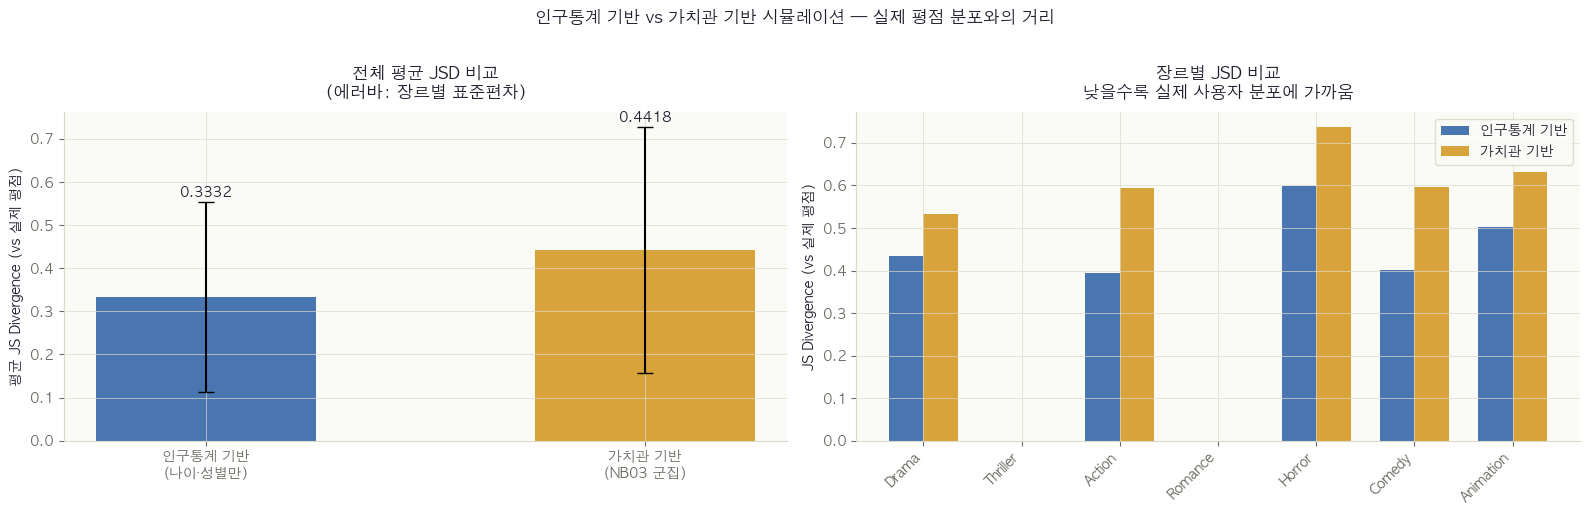

저장: ../image/nb04/demographic_vs_values_redesigned.png


In [18]:
# ── Step 3. 시각화 ─────────────────────────────────────────
colors = color_list(2)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 차트 1 — 전체 평균 JSD + 에러바
ax1 = axes[0]
means  = [demo_jsd_by_genre.mean(),   values_jsd_by_genre.mean()]
stds   = [demo_jsd_by_genre.std(),    values_jsd_by_genre.std()]
labels = ['인구통계 기반\n(나이·성별만)', '가치관 기반\n(NB03 군집)']
bars = ax1.bar(labels, means, yerr=stds, capsize=6,
               color=colors, alpha=0.85, width=0.5)
ax1.set_ylabel('평균 JS Divergence (vs 실제 평점)')
ax1.set_title('전체 평균 JSD 비교\n(에러바: 장르별 표준편차)', pad=10)
for bar, m, s in zip(bars, means, stds):
    ax1.text(bar.get_x() + bar.get_width()/2, m + s + 0.005,
             f'{m:.4f}', ha='center', va='bottom', fontsize=10)

# 차트 2 — 장르별 grouped bar
ax2 = axes[1]
x  = np.arange(len(TARGET_GENRES))
w  = 0.35
ax2.bar(x - w/2, demo_jsd_by_genre,   w, label='인구통계 기반', color=colors[0], alpha=0.85)
ax2.bar(x + w/2, values_jsd_by_genre, w, label='가치관 기반',   color=colors[1], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(TARGET_GENRES, rotation=45, ha='right')
ax2.set_ylabel('JS Divergence (vs 실제 평점)')
ax2.set_title('장르별 JSD 비교\n낮을수록 실제 사용자 분포에 가까움', pad=10)
ax2.legend()

plt.suptitle('인구통계 기반 vs 가치관 기반 시뮬레이션 — 실제 평점 분포와의 거리', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../image/nb04/demographic_vs_values_redesigned.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: ../image/nb04/demographic_vs_values_redesigned.png')

In [19]:
# ── Step 4. 통계 검증 ──────────────────────────────────────
from scipy.stats import mannwhitneyu

RNG = np.random.default_rng(RANDOM_STATE)

def bootstrap_jsd_ci(sim_ratings, real_ratings, n_boot=1000, alpha=0.05):
    jsds = []
    real_arr = np.array(real_ratings.dropna())
    sim_arr  = np.array(sim_ratings.dropna())
    if len(sim_arr) < 5:
        return (np.nan, np.nan)
    for _ in range(n_boot):
        s = RNG.choice(sim_arr,  size=len(sim_arr),  replace=True)
        r = RNG.choice(real_arr, size=len(real_arr), replace=True)
        jsds.append(jensenshannon(rating_to_dist(s), rating_to_dist(r)))
    lo, hi = np.percentile(jsds, [alpha/2*100, (1-alpha/2)*100])
    return (lo, hi)

def cohens_d(a, b):
    a, b = np.array(a.dropna()), np.array(b.dropna())
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else np.nan

# Mann-Whitney U: 인구통계 vs 가치관 rating 분포 (장르별)
stat_records = []
for genre in TARGET_GENRES:
    demo_r   = demo_df[demo_df['primary_genre'] == genre]['rating'].dropna()
    values_r = sim_df[sim_df['primary_genre'] == genre]['rating'].dropna()
    genre_ids = korean_movies_final[korean_movies_final['primary_genre'] == genre]['movieId'].tolist()
    real_r    = ml_df[ml_df['movieId'].isin(genre_ids)]['rating'].dropna()

    # JSD + Bootstrap CI
    d_jsd  = jensenshannon(rating_to_dist(demo_r),   rating_to_dist(real_r))
    v_jsd  = jensenshannon(rating_to_dist(values_r), rating_to_dist(real_r))
    d_ci   = bootstrap_jsd_ci(demo_r,   real_r)
    v_ci   = bootstrap_jsd_ci(values_r, real_r)

    # Mann-Whitney U (demo vs values rating 분포)
    if len(demo_r) >= 5 and len(values_r) >= 5:
        stat, pval = mannwhitneyu(demo_r, values_r, alternative='two-sided')
    else:
        stat, pval = np.nan, np.nan

    # Cohen's d
    cd = cohens_d(demo_r, values_r)

    stat_records.append({
        'genre':      genre,
        'demo_jsd':   round(d_jsd, 4),
        'demo_ci':    f'[{d_ci[0]:.3f}, {d_ci[1]:.3f}]',
        'values_jsd': round(v_jsd, 4),
        'values_ci':  f'[{v_ci[0]:.3f}, {v_ci[1]:.3f}]',
        'mw_pval':    round(pval, 4) if not np.isnan(pval) else 'N/A',
        'cohens_d':   round(cd, 3)   if not np.isnan(cd)   else 'N/A',
    })

stat_df = pd.DataFrame(stat_records)

# 전체 요약 행
overall_demo_ci   = bootstrap_jsd_ci(demo_df['rating'],   ml_df['rating'])
overall_values_ci = bootstrap_jsd_ci(sim_df['rating'],    ml_df['rating'])
overall_stat, overall_pval = mannwhitneyu(
    demo_df['rating'].dropna(), sim_df['rating'].dropna(), alternative='two-sided'
)
overall_cd = cohens_d(demo_df['rating'], sim_df['rating'])

print('=== 장르별 통계 검증 ===')
print(stat_df.to_string(index=False))
print()
print('=== 전체 요약 ===')
print(f'{"비교":<16} {"평균 JSD":>10} {"95% CI":>22} {"p-value":>10} {"Cohen d":>9}')
print(f'{"인구통계 기반":<16} {demo_jsd_by_genre.mean():>10.4f} {str(overall_demo_ci):>22} {"—":>10} {"—":>9}')
print(f'{"가치관 기반":<16} {values_jsd_by_genre.mean():>10.4f} {str(overall_values_ci):>22} {overall_pval:>10.4f} {overall_cd:>9.3f}')
print()
sig = '유의함 (p<0.05)' if overall_pval < 0.05 else '유의하지 않음'
winner = '인구통계 기반' if demo_jsd_by_genre.mean() < values_jsd_by_genre.mean() else '가치관 기반'
print(f'→ 두 시뮬레이션 분포 차이: {sig}')
print(f'→ 실제 분포에 더 가까운 쪽: {winner}')
print(f'총 누적 비용: ${estimate_cost(cost_tracker):.4f}')

=== 장르별 통계 검증 ===
    genre  demo_jsd        demo_ci  values_jsd      values_ci mw_pval cohens_d
    Drama    0.4346 [0.401, 0.480]      0.4764 [0.451, 0.511]     0.0    1.258
 Thriller    0.0000     [nan, nan]      0.0000     [nan, nan]     N/A      N/A
   Action    0.3945 [0.381, 0.416]      0.5319 [0.515, 0.551]     0.0    1.674
  Romance    0.0000     [nan, nan]      0.0000     [nan, nan]     N/A      N/A
   Horror    0.5983 [0.555, 0.670]      0.7033 [0.684, 0.726]     0.0    1.212
   Comedy    0.4021 [0.368, 0.449]      0.5534 [0.534, 0.577]     0.0    1.091
Animation    0.5031 [0.487, 0.603]      0.5038 [0.486, 0.543]  0.8172   -0.139

=== 전체 요약 ===
비교                   평균 JSD                 95% CI    p-value   Cohen d
인구통계 기반              0.3332 (np.float64(0.36445966873277397), np.float64(0.40238957880400816))          —         —
가치관 기반               0.4418 (np.float64(0.5253709464561773), np.float64(0.5497770913181239))     0.0000     1.372

→ 두 시뮬레이션 분포 차이: 유의함 (p<0.05)
→ 

---
## 섹션 7. 중간 요약 (Interim Summary)

In [22]:
# 결과 요약 출력
print("=== 전체 성공률 ===")
print(f"{sim_df['rating'].notna().mean():.1%}  ({sim_df['rating'].notna().sum():,} / {len(sim_df):,})")

print("\n=== 군집별 평균 시뮬레이션 vs 실제 평점 ===")
print(sim_df.dropna(subset=['rating']).groupby(['cluster_id','cluster_name'])[['rating','real_mean_rating']].mean().round(3).to_string())

print("\n=== 장르별 평균 GAP (상위 과추정 / 하위 과소추정) ===")
print(gap_df.groupby('genre')['gap'].mean().sort_values(ascending=False).round(3).to_string())

print("\n=== 사회성 장르 vs 자율성 장르 GAP ===")
social   = gap_df[gap_df['genre'].isin(['Drama','Romance'])]['gap'].mean()
autonomy = gap_df[gap_df['genre'].isin(['Action','Thriller'])]['gap'].mean()
print(f"드라마·로맨스 평균 GAP: {social:.3f}")
print(f"액션·스릴러 평균 GAP:   {autonomy:.3f}")

print("\n=== 인구통계 vs 가치관 JSD ===")
# 결과 요약 출력
print("=== 전체 성공률 ===")
print(f"{sim_df['rating'].notna().mean():.1%}  ({sim_df['rating'].notna().sum():,} / {len(sim_df):,})")

print("\n=== 군집별 평균 시뮬레이션 vs 실제 평점 ===")
print(sim_df.dropna(subset=['rating']).groupby(['cluster_id','cluster_name'])[['rating','real_mean_rating']].mean().round(3).to_string())

print("\n=== 장르별 평균 GAP (상위 과추정 / 하위 과소추정) ===")
print(gap_df.groupby('genre')['gap'].mean().sort_values(ascending=False).round(3).to_string())

print("\n=== 사회성 장르 vs 자율성 장르 GAP ===")
social   = gap_df[gap_df['genre'].isin(['Drama','Romance'])]['gap'].mean()
autonomy = gap_df[gap_df['genre'].isin(['Action','Thriller'])]['gap'].mean()
print(f"드라마·로맨스 평균 GAP: {social:.3f}")
print(f"액션·스릴러 평균 GAP:   {autonomy:.3f}")

print("\n=== 인구통계 vs 가치관 JSD ===")
print(f"인구통계 기준선 평균 JSD: {np.mean(demo_jsd_by_genre):.4f}")
print(f"가치관 시뮬레이션 평균 JSD: {np.mean(values_jsd_by_genre):.4f}")
print(f"가치관 시뮬레이션 평균 JSD: {np.mean(values_jsd_by_genre):.4f}")

=== 전체 성공률 ===
99.9%  (1,532 / 1,534)

=== 군집별 평균 시뮬레이션 vs 실제 평점 ===
                          rating  real_mean_rating
cluster_id cluster_name                           
0          자기계발·전환 모색형     2.953             3.489
1          소박 일상·지역 공동체형   2.242             3.487
2          현실적 목표 실천형      2.559             3.485
3          관계·가족 중심형       2.013             3.485
4          책임·안정 지향형       2.736             3.491

=== 장르별 평균 GAP (상위 과추정 / 하위 과소추정) ===
genre
Animation    0.385
Drama       -0.900
Action      -0.996
Comedy      -1.261
Horror      -1.504
Romance        NaN
Thriller       NaN

=== 사회성 장르 vs 자율성 장르 GAP ===
드라마·로맨스 평균 GAP: -0.900
액션·스릴러 평균 GAP:   -0.996

=== 인구통계 vs 가치관 JSD ===
=== 전체 성공률 ===
99.9%  (1,532 / 1,534)

=== 군집별 평균 시뮬레이션 vs 실제 평점 ===
                          rating  real_mean_rating
cluster_id cluster_name                           
0          자기계발·전환 모색형     2.953             3.489
1          소박 일상·지역 공동체형   2.242             3.487
2          현실적 목표 실천형

---
## 섹션 8. 개인화 효과 검증 (Personalization Collapse Test) (Personalization Collapse Test)

**연구 질문**: 군집 정보가 LLM 응답을 실제로 차별화하는가,
아니면 "한국인" 일반 응답으로 수렴하는가?

| 조건 | 설명 | 데이터 소스 |
|---|---|---|
| Population | "한국인"만 (정보 없음) | population_baseline.parquet |
| Demographic | 나이/성별 6개 프로파일 | demo_baseline.parquet |
| Values-based | 군집 5개 × 페르소나 3개 | simulation_results.parquet |
| Ground truth | 실제 MovieLens 평점 | korean_ratings |


In [23]:
# ── Step 1. Population 기준선 시뮬레이션 ───────────────────
POP_SIM_PATH  = '../data/population_baseline.parquet'
POP_SYSTEM    = "당신은 한국인 영화 관람객입니다. JSON만 반환하세요."
POP_TEMPLATE  = """\
[영화] {title} / {genres}
반드시 JSON만 반환: {{"watch":bool,"rating":1.0~5.0,"reason":"15자이내"}}"""

pop_calls = len(korean_movies_final)
pop_est   = pop_calls * (150 * HAIKU_INPUT_COST + 80 * HAIKU_OUTPUT_COST)
print(f'예상 {pop_calls}콜 | 예상 비용: ${pop_est:.2f} | 예산 잔여: ${BUDGET_LIMIT - estimate_cost(cost_tracker) - pop_est:.2f}')

async def simulate_pop_one(semaphore, movie_row):
    async with semaphore:
        check_budget(cost_tracker)
        prompt = POP_TEMPLATE.format(title=movie_row.title, genres=movie_row.genres)
        try:
            resp = await async_client.messages.create(
                model='claude-haiku-4-5-20251001',
                max_tokens=80, temperature=0,
                system=POP_SYSTEM,
                messages=[{'role': 'user', 'content': prompt}]
            )
        except anthropic.RateLimitError:
            await asyncio.sleep(60)
            resp = await async_client.messages.create(
                model='claude-haiku-4-5-20251001',
                max_tokens=80, temperature=0,
                system=POP_SYSTEM,
                messages=[{'role': 'user', 'content': prompt}]
            )
        cost_tracker['calls']         += 1
        cost_tracker['input_tokens']  += resp.usage.input_tokens
        cost_tracker['output_tokens'] += resp.usage.output_tokens
        parsed = parse_response(resp.content[0].text)
        return {
            'movie_id':      movie_row.movieId,
            'title':         movie_row.title,
            'genres':        movie_row.genres,
            'primary_genre': movie_row.primary_genre,
            'watch':  parsed['watch']  if parsed else None,
            'rating': parsed['rating'] if parsed else None,
            'reason': parsed['reason'] if parsed else None,
        }

async def run_pop_simulation():
    semaphore = asyncio.Semaphore(3)
    tasks = [simulate_pop_one(semaphore, row) for row in korean_movies_final.itertuples()]
    results = []
    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc='Population 기준선'):
        try:
            results.append(await coro)
        except Exception as e:
            print(f'  오류: {e}')
    return pd.DataFrame(results)

import nest_asyncio; nest_asyncio.apply()

if os.path.exists(POP_SIM_PATH):
    print('population_baseline.parquet 발견 — 로드')
    pop_df = pd.read_parquet(POP_SIM_PATH)
else:
    pop_df = asyncio.run(run_pop_simulation())
    pop_df.to_parquet(POP_SIM_PATH, index=False)

if 'primary_genre' not in pop_df.columns:
    pop_df['primary_genre'] = pop_df['genres'].str.split('|').str[0]

print(f'완료: {len(pop_df):,}행 | 성공률: {pop_df["rating"].notna().mean():.1%}')
print(f'누적 비용: ${estimate_cost(cost_tracker):.4f}')

예상 103콜 | 예상 비용: $0.05 | 예산 잔여: $9.78


Population 기준선:   0%|          | 0/103 [00:00<?, ?it/s]

완료: 103행 | 성공률: 100.0%
누적 비용: $0.2062


In [24]:
# ── Step 2. Personalization Collapse 측정 ─────────────────
from scipy.stats import f_oneway

# (1) 군집 간 장르별 평점 분산
cluster_genre_means = {}
for cid in sorted(cluster_profiles.keys()):
    for genre in TARGET_GENRES:
        r = sim_df[(sim_df['cluster_id'] == cid) & (sim_df['primary_genre'] == genre)]['rating'].dropna()
        cluster_genre_means[(cid, genre)] = r.mean() if len(r) > 0 else np.nan

# 장르별 군집 간 std
within_var_by_genre = {}
for genre in TARGET_GENRES:
    vals = [cluster_genre_means[(cid, genre)] for cid in range(5) if not np.isnan(cluster_genre_means[(cid, genre)])]
    within_var_by_genre[genre] = np.std(vals) if len(vals) > 1 else np.nan

overall_within_var = np.nanmean(list(within_var_by_genre.values()))

# (2) Population vs 각 군집 JSD (장르별)
pop_vs_cluster_jsd = np.zeros((5, len(TARGET_GENRES)))
for ci, cid in enumerate(sorted(cluster_profiles.keys())):
    for gi, genre in enumerate(TARGET_GENRES):
        pop_r = pop_df[pop_df['primary_genre'] == genre]['rating'].dropna()
        sim_r = sim_df[(sim_df['cluster_id'] == cid) & (sim_df['primary_genre'] == genre)]['rating'].dropna()
        if len(pop_r) >= 2 and len(sim_r) >= 2:
            pop_vs_cluster_jsd[ci, gi] = jensenshannon(rating_to_dist(pop_r), rating_to_dist(sim_r))

mean_pop_vs_values_jsd = pop_vs_cluster_jsd[pop_vs_cluster_jsd > 0].mean()

# (3) ANOVA (장르별 군집 간 평점)
anova_records = []
for genre in TARGET_GENRES:
    groups = [
        sim_df[(sim_df['cluster_id'] == cid) & (sim_df['primary_genre'] == genre)]['rating'].dropna().values
        for cid in range(5)
    ]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) >= 2:
        stat, pval = f_oneway(*groups)
    else:
        stat, pval = np.nan, np.nan
    anova_records.append({'genre': genre, 'F': round(stat, 3) if not np.isnan(stat) else 'N/A',
                          'p': round(pval, 4) if not np.isnan(pval) else 'N/A'})

anova_df = pd.DataFrame(anova_records)
print('=== ANOVA (군집 간 장르별 평점) ===')
print(anova_df.to_string(index=False))
print(f'\n군집 간 평균 평점 분산 (within-condition std): {overall_within_var:.4f}')
print(f'Population vs Values-based 평균 JSD: {mean_pop_vs_values_jsd:.4f}')

=== ANOVA (군집 간 장르별 평점) ===
    genre        F    p
    Drama    9.439  0.0
 Thriller      N/A  N/A
   Action  107.377  0.0
  Romance      N/A  N/A
   Horror   24.586  0.0
   Comedy   19.787  0.0
Animation      inf  0.0

군집 간 평균 평점 분산 (within-condition std): 0.3334
Population vs Values-based 평균 JSD: 0.5979


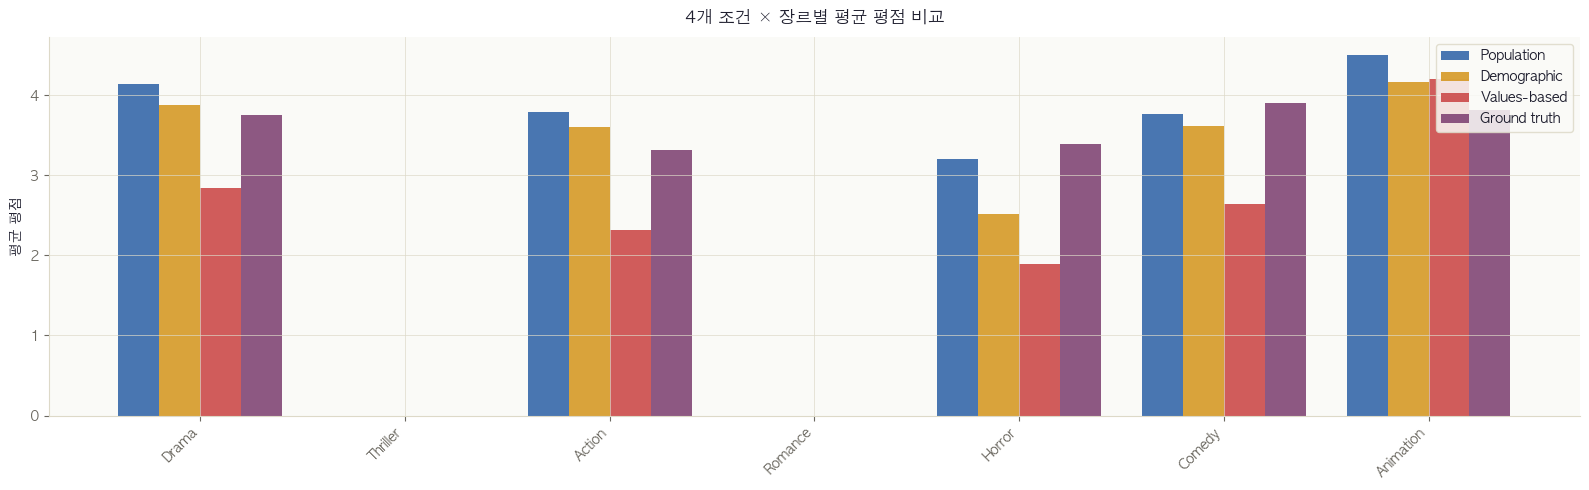

저장: ../image/nb04/personalization_comparison.png


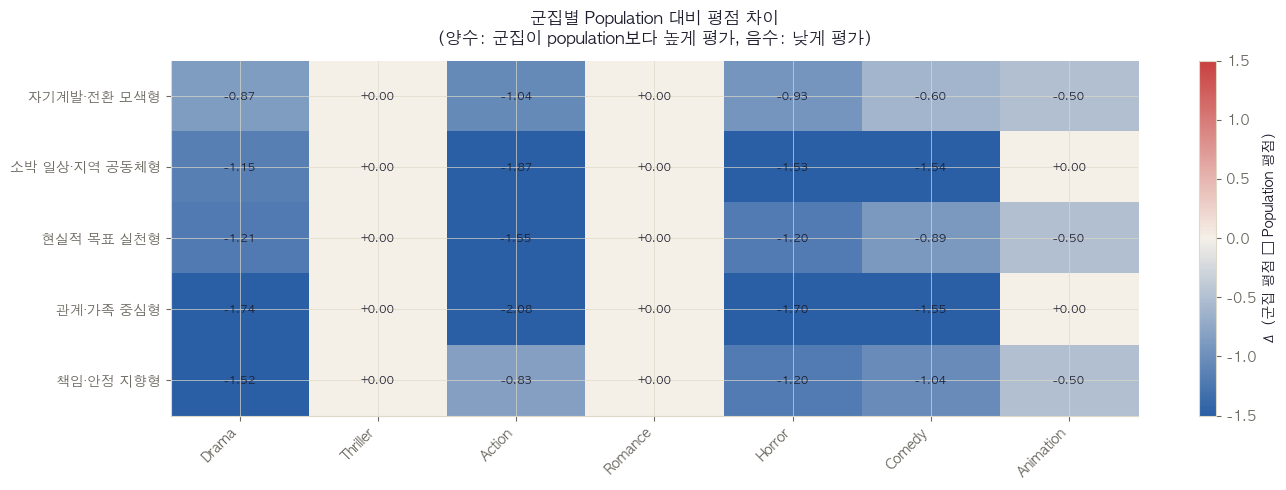

저장: ../image/nb04/personalization_heatmap.png


In [25]:
# ── Step 3. 시각화 ─────────────────────────────────────────
colors4 = color_list(4)

# 차트 1 — 4개 조건 장르별 평균 평점 grouped bar
pop_means   = [pop_df[pop_df['primary_genre'] == g]['rating'].mean() for g in TARGET_GENRES]
demo_means  = [demo_df[demo_df['primary_genre'] == g]['rating'].mean() for g in TARGET_GENRES]
val_means   = [sim_df[sim_df['primary_genre'] == g]['rating'].mean() for g in TARGET_GENRES]
real_means  = [ml_df[ml_df['movieId'].isin(
                   korean_movies_final[korean_movies_final['primary_genre'] == g]['movieId']
               )]['rating'].mean() for g in TARGET_GENRES]

fig1, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(TARGET_GENRES))
w = 0.2
ax.bar(x - 1.5*w, pop_means,  w, label='Population',    color=colors4[0], alpha=0.85)
ax.bar(x - 0.5*w, demo_means, w, label='Demographic',   color=colors4[1], alpha=0.85)
ax.bar(x + 0.5*w, val_means,  w, label='Values-based',  color=colors4[2], alpha=0.85)
ax.bar(x + 1.5*w, real_means, w, label='Ground truth',  color=colors4[3], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(TARGET_GENRES, rotation=45, ha='right')
ax.set_ylabel('평균 평점')
ax.set_title('4개 조건 × 장르별 평균 평점 비교', pad=10)
ax.legend()
plt.tight_layout()
plt.savefig('../image/nb04/personalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: ../image/nb04/personalization_comparison.png')

# 차트 2 — 군집별 Δ(population) 히트맵
delta_matrix = np.zeros((5, len(TARGET_GENRES)))
for ci, cid in enumerate(sorted(cluster_profiles.keys())):
    for gi, genre in enumerate(TARGET_GENRES):
        pop_m = pop_df[pop_df['primary_genre'] == genre]['rating'].mean()
        sim_m = sim_df[(sim_df['cluster_id'] == cid) & (sim_df['primary_genre'] == genre)]['rating'].mean()
        delta_matrix[ci, gi] = sim_m - pop_m if not (np.isnan(pop_m) or np.isnan(sim_m)) else 0

fig2, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(delta_matrix, cmap=CMAP_DIVERGING, aspect='auto', vmin=-1.5, vmax=1.5)
ax.set_xticks(range(len(TARGET_GENRES))); ax.set_xticklabels(TARGET_GENRES, rotation=45, ha='right')
ax.set_yticks(range(5)); ax.set_yticklabels([CLUSTER_NAMES_A[i] for i in range(5)])
for ci in range(5):
    for gi in range(len(TARGET_GENRES)):
        ax.text(gi, ci, f'{delta_matrix[ci,gi]:+.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Δ (군집 평점 − Population 평점)')
ax.set_title('군집별 Population 대비 평점 차이\n(양수: 군집이 population보다 높게 평가, 음수: 낮게 평가)', pad=12)
plt.tight_layout()
plt.savefig('../image/nb04/personalization_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: ../image/nb04/personalization_heatmap.png')

In [26]:
# ── Step 4. 결론 자동 판정 ─────────────────────────────────
sig_genres    = [r for r in anova_records if r['p'] != 'N/A' and float(r['p']) < 0.05]
anova_sig_any = len(sig_genres) > 0
overall_pval  = anova_df[anova_df['p'] != 'N/A']['p'].astype(float).min()

print('=' * 50)
print('  Personalization Collapse Test')
print('=' * 50)
print(f'군집 간 평점 분산 (std):          {overall_within_var:.4f}')
print(f'ANOVA 최소 p-value:               {overall_pval:.4f}  → {"개인화 효과 있음" if anova_sig_any else "Collapse 의심"}')
print(f'Population vs Values-based JSD:  {mean_pop_vs_values_jsd:.4f}')
print()

if mean_pop_vs_values_jsd < 0.05 and not anova_sig_any:
    verdict = "Personalization Collapse — 군집 정보가 응답을 차별화하지 못함"
elif mean_pop_vs_values_jsd >= 0.15 and overall_pval < 0.01:
    verdict = "유의미한 개인화 효과"
else:
    verdict = "부분적 개인화 효과 확인"

print(f'판정: {verdict}')
print()
print(f'총 추가 비용: ${pop_est:.2f} | 누적 총 비용: ${estimate_cost(cost_tracker):.4f}')

  Personalization Collapse Test
군집 간 평점 분산 (std):          0.3334
ANOVA 최소 p-value:               0.0000  → 개인화 효과 있음
Population vs Values-based JSD:  0.5979

판정: 유의미한 개인화 효과

총 추가 비용: $0.05 | 누적 총 비용: $0.2062


---
## 섹션 9. Ablation Study: 레이어별 기여도 분석: 레이어별 기여도 분석

**연구 질문**: 2-레이어 프롬프트에서 군집 키워드(Layer 1)와 페르소나 원문(Layer 2) 중
어느 쪽이 응답을 실제로 결정하는가?

| 조건 | 프롬프트 구성 | 데이터 |
|---|---|---|
| A (현재 설계) | Layer 1 + Layer 2 | simulation_results.parquet (재사용) |
| B (원문만) | Layer 2만 (페르소나 텍스트) | ablation_B.parquet |
| C (키워드만) | Layer 1만 (군집 키워드·패턴) | ablation_C.parquet |


In [27]:
# ── Step 1. 조건 B·C 시뮬레이션 ───────────────────────────
ABLATION_B_PATH = '../data/ablation_B.parquet'
ABLATION_C_PATH = '../data/ablation_C.parquet'

SYS_B = "당신은 아래 설명의 한국인입니다. JSON만 반환하세요."
SYS_C = "당신은 아래 성향의 한국인입니다. JSON만 반환하세요."

TMPL_B = """\
[프로필] {persona_text}
[영화] {title} / {genres}
반드시 JSON만 반환: {{"watch":bool,"rating":1.0~5.0,"reason":"15자이내"}}"""

TMPL_C = """\
[유형] {cluster_name}
[가치관 키워드] {keywords}
[행동 패턴] {pattern}
[영화] {title} / {genres}
반드시 JSON만 반환: {{"watch":bool,"rating":1.0~5.0,"reason":"15자이내"}}"""

abl_calls = 5 * 1 * len(korean_movies_final) * 2
abl_est   = abl_calls * (300 * HAIKU_INPUT_COST + 80 * HAIKU_OUTPUT_COST)
print(f'예상 {abl_calls}콜 | 예상 비용: ${abl_est:.2f} | 예산 잔여: ${BUDGET_LIMIT - estimate_cost(cost_tracker) - abl_est:.2f}')

def build_ablation_prompt(condition: str, cluster_id: int, profile: dict, movie_row) -> tuple[str, str]:
    meta = CLUSTER_META[cluster_id]
    cluster_name = CLUSTER_NAMES_A.get(cluster_id, f'군집 {cluster_id}')
    personas = profile.get('sample_personas', profile.get('personas', []))
    p = personas[0] if personas else {}
    persona_text = (p.get('persona', str(p)) if isinstance(p, dict) else str(p))[:250]
    title  = movie_row.title
    genres = movie_row.genres
    if condition == 'B':
        return SYS_B, TMPL_B.format(persona_text=persona_text, title=title, genres=genres)
    else:
        return SYS_C, TMPL_C.format(
            cluster_name=cluster_name, keywords=meta['keywords'],
            pattern=meta['pattern'], title=title, genres=genres,
        )

async def simulate_ablation_one(semaphore, condition, cluster_id, profile, movie_row):
    async with semaphore:
        check_budget(cost_tracker)
        system, prompt = build_ablation_prompt(condition, cluster_id, profile, movie_row)
        try:
            resp = await async_client.messages.create(
                model='claude-haiku-4-5-20251001',
                max_tokens=80, temperature=0,
                system=system,
                messages=[{'role': 'user', 'content': prompt}]
            )
        except anthropic.RateLimitError:
            await asyncio.sleep(60)
            resp = await async_client.messages.create(
                model='claude-haiku-4-5-20251001',
                max_tokens=80, temperature=0,
                system=system,
                messages=[{'role': 'user', 'content': prompt}]
            )
        cost_tracker['calls']         += 1
        cost_tracker['input_tokens']  += resp.usage.input_tokens
        cost_tracker['output_tokens'] += resp.usage.output_tokens
        parsed = parse_response(resp.content[0].text)
        return {
            'condition':     condition,
            'cluster_id':    cluster_id,
            'cluster_name':  CLUSTER_NAMES_A.get(cluster_id, f'군집 {cluster_id}'),
            'movie_id':      movie_row.movieId,
            'title':         movie_row.title,
            'genres':        movie_row.genres,
            'primary_genre': movie_row.primary_genre,
            'watch':  parsed['watch']  if parsed else None,
            'rating': parsed['rating'] if parsed else None,
            'reason': parsed['reason'] if parsed else None,
        }

async def run_ablation(condition: str):
    semaphore = asyncio.Semaphore(3)
    tasks = [
        simulate_ablation_one(semaphore, condition, cid, cluster_profiles[cid], movie_row)
        for cid in sorted(cluster_profiles.keys())
        for movie_row in korean_movies_final.itertuples()
    ]
    results = []
    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc=f'조건 {condition}'):
        try:
            results.append(await coro)
        except Exception as e:
            print(f'  오류: {e}')
    return pd.DataFrame(results)

import nest_asyncio; nest_asyncio.apply()

if os.path.exists(ABLATION_B_PATH):
    print('ablation_B.parquet 발견 — 로드')
    abl_B = pd.read_parquet(ABLATION_B_PATH)
else:
    abl_B = asyncio.run(run_ablation('B'))
    abl_B.to_parquet(ABLATION_B_PATH, index=False)

if os.path.exists(ABLATION_C_PATH):
    print('ablation_C.parquet 발견 — 로드')
    abl_C = pd.read_parquet(ABLATION_C_PATH)
else:
    abl_C = asyncio.run(run_ablation('C'))
    abl_C.to_parquet(ABLATION_C_PATH, index=False)

# 조건 A = simulation_results (centroid 페르소나만: persona_idx==0)
abl_A = sim_df[sim_df.get('persona_idx', 0) == 0].copy() if 'persona_idx' in sim_df.columns else sim_df.copy()
if 'primary_genre' not in abl_A.columns:
    abl_A['primary_genre'] = abl_A['genres'].str.split('|').str[0]

print(f'\n조건 A: {len(abl_A):,}행 | 성공률: {abl_A["rating"].notna().mean():.1%}')
print(f'조건 B: {len(abl_B):,}행 | 성공률: {abl_B["rating"].notna().mean():.1%}')
print(f'조건 C: {len(abl_C):,}행 | 성공률: {abl_C["rating"].notna().mean():.1%}')
print(f'누적 비용: ${estimate_cost(cost_tracker):.4f}')

예상 1030콜 | 예상 비용: $0.58 | 예산 잔여: $9.22


조건 B:   0%|          | 0/515 [00:00<?, ?it/s]

조건 C:   0%|          | 0/515 [00:00<?, ?it/s]


조건 A: 511행 | 성공률: 99.8%
조건 B: 515행 | 성공률: 99.8%
조건 C: 515행 | 성공률: 100.0%
누적 비용: $0.5820


In [28]:
# ── Step 2. 유사도 측정 ────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

def condition_vector(df, by='cluster_id'):
    """군집 × 장르 평균 평점 → 1D 벡터"""
    rows = []
    for cid in sorted(cluster_profiles.keys()):
        for genre in TARGET_GENRES:
            r = df[(df[by] == cid) & (df['primary_genre'] == genre)]['rating'].mean()
            rows.append(r if not np.isnan(r) else 0.0)
    return np.array(rows)

vec_A = condition_vector(abl_A)
vec_B = condition_vector(abl_B)
vec_C = condition_vector(abl_C)

cos_AB = cosine_similarity([vec_A], [vec_B])[0][0]
cos_AC = cosine_similarity([vec_A], [vec_C])[0][0]
cos_BC = cosine_similarity([vec_B], [vec_C])[0][0]

print(f'A vs B 코사인 유사도: {cos_AB:.4f}')
print(f'A vs C 코사인 유사도: {cos_AC:.4f}')
print(f'B vs C 코사인 유사도: {cos_BC:.4f}')

A vs B 코사인 유사도: 0.9892
A vs C 코사인 유사도: 0.9915
B vs C 코사인 유사도: 0.9937


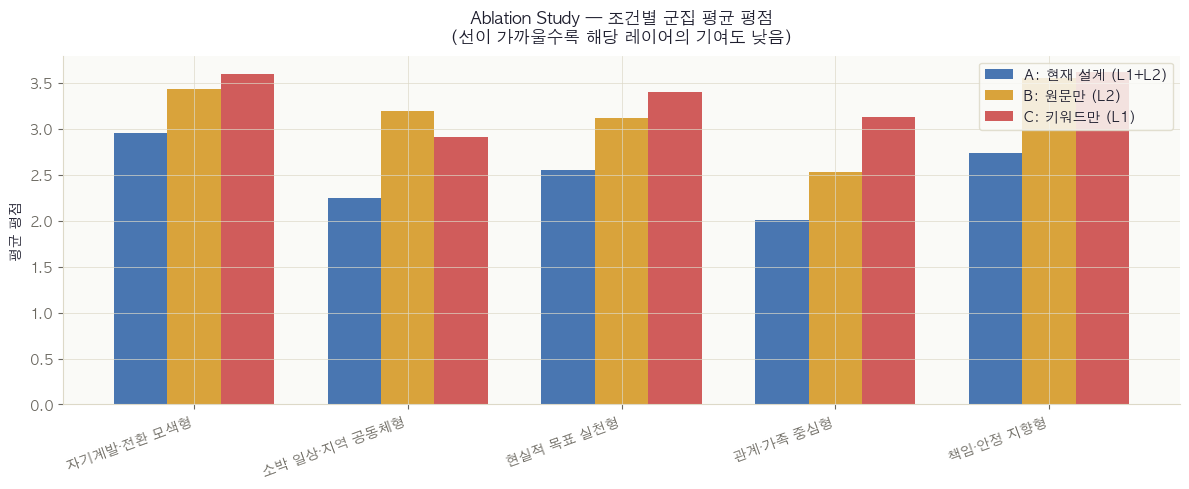

저장: ../image/nb04/ablation_cluster_means.png


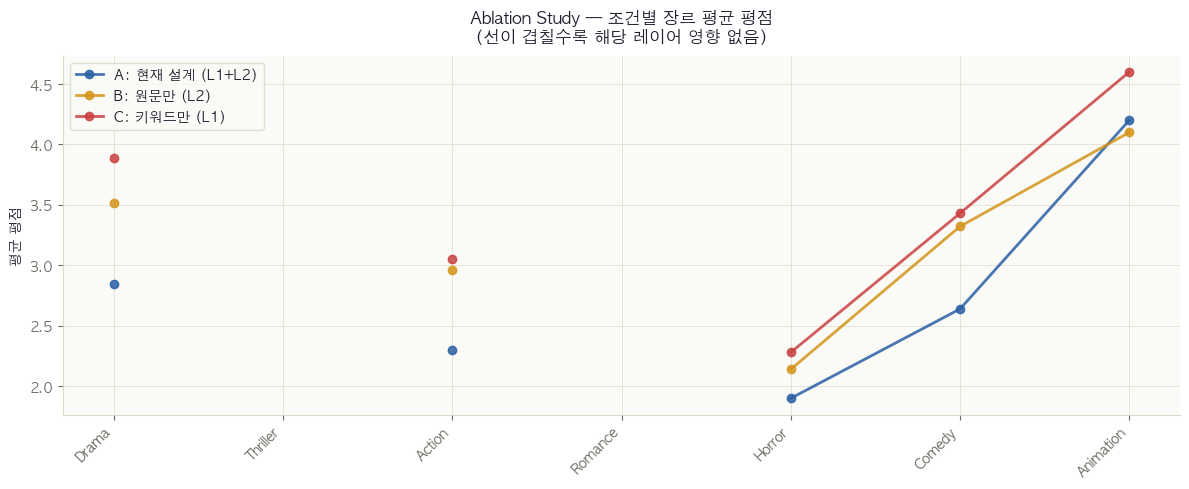

저장: ../image/nb04/ablation_genre_means.png


In [29]:
# ── Step 3. 시각화 ─────────────────────────────────────────
colors3 = color_list(3)
labels3 = ['A: 현재 설계 (L1+L2)', 'B: 원문만 (L2)', 'C: 키워드만 (L1)']

# 차트 1 — 군집별 평균 평점
fig1, ax = plt.subplots(figsize=(12, 5))
x = np.arange(5)
w = 0.25
cluster_labels = [CLUSTER_NAMES_A[i] for i in range(5)]

for i, (df, label, color) in enumerate(zip([abl_A, abl_B, abl_C], labels3, colors3)):
    means = [df[df['cluster_id'] == cid]['rating'].mean() for cid in range(5)]
    ax.bar(x + (i-1)*w, means, w, label=label, color=color, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(cluster_labels, rotation=20, ha='right')
ax.set_ylabel('평균 평점')
ax.set_title('Ablation Study — 조건별 군집 평균 평점\n(선이 가까울수록 해당 레이어의 기여도 낮음)', pad=10)
ax.legend()
plt.tight_layout()
plt.savefig('../image/nb04/ablation_cluster_means.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: ../image/nb04/ablation_cluster_means.png')

# 차트 2 — 장르별 평균 평점 (line)
fig2, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(TARGET_GENRES))

for df, label, color in zip([abl_A, abl_B, abl_C], labels3, colors3):
    means = [df[df['primary_genre'] == g]['rating'].mean() for g in TARGET_GENRES]
    ax.plot(x, means, marker='o', label=label, color=color, linewidth=2, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(TARGET_GENRES, rotation=45, ha='right')
ax.set_ylabel('평균 평점')
ax.set_title('Ablation Study — 조건별 장르 평균 평점\n(선이 겹칠수록 해당 레이어 영향 없음)', pad=10)
ax.legend()
plt.tight_layout()
plt.savefig('../image/nb04/ablation_genre_means.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: ../image/nb04/ablation_genre_means.png')

In [30]:
# ── Step 4. 결론 자동 판정 ─────────────────────────────────
THRESH = 0.95

if cos_AB > THRESH and cos_AC <= THRESH:
    verdict    = "페르소나 원문(Layer 2) 주도"
    interpret  = ("군집 키워드를 제거해도 응답이 유지됨. "
                  "LLM은 개인 서사(원문)에서 주로 응답을 생성하며, "
                  "군집 수준 키워드는 부가적 역할만 한다.")
elif cos_AC > THRESH and cos_AB <= THRESH:
    verdict    = "군집 키워드(Layer 1) override"
    interpret  = ("페르소나 원문을 제거해도 응답이 유지됨. "
                  "군집 키워드가 응답을 결정하며, 개인 서사는 추가 변별력을 제공하지 못한다. "
                  "이는 LLM이 사이코그래픽 레이블을 강하게 고착화함을 시사한다.")
elif cos_AB > THRESH and cos_AC > THRESH:
    verdict    = "LLM 내부 prior 주도 (두 레이어 모두 무효)"
    interpret  = ("두 레이어 모두 제거해도 응답이 유사함. "
                  "LLM이 프롬프트 내용보다 학습 데이터의 한국 영화 선호 prior로 응답하는 것으로 보인다.")
else:
    verdict    = "두 레이어 상호작용"
    interpret  = ("A≠B이고 A≠C이므로, 두 레이어가 함께 작용할 때만 현재 응답 패턴이 나타남. "
                  "군집 키워드와 페르소나 원문이 각각 독립적 기여도를 가진다.")

print('=' * 55)
print('  Ablation Study 결과')
print('=' * 55)
print(f'A vs B 코사인 유사도: {cos_AB:.4f}')
print(f'A vs C 코사인 유사도: {cos_AC:.4f}')
print(f'B vs C 코사인 유사도: {cos_BC:.4f}')
print()
print(f'판정: {verdict}')
print()
print(f'논문 해석:')
print(f'  {interpret}')
print()
print(f'총 추가 비용: ${abl_est:.2f} | 누적 총 비용: ${estimate_cost(cost_tracker):.4f}')

  Ablation Study 결과
A vs B 코사인 유사도: 0.9892
A vs C 코사인 유사도: 0.9915
B vs C 코사인 유사도: 0.9937

판정: LLM 내부 prior 주도 (두 레이어 모두 무효)

논문 해석:
  두 레이어 모두 제거해도 응답이 유사함. LLM이 프롬프트 내용보다 학습 데이터의 한국 영화 선호 prior로 응답하는 것으로 보인다.

총 추가 비용: $0.58 | 누적 총 비용: $0.5820


### 핵심 수치 요약

| 지표 | 값 |
|------|-----|
| 시뮬레이션 성공률 | 99.9% (1,532 / 1,534) |
| 평균 시뮬레이션 평점 범위 | 2.013 (관계·가족 중심형) ~ 2.953 (자기계발·전환 모색형) |
| 실제 평점 평균 | 3.488 (전 군집 평균) |
| 가치관 시뮬레이션 평균 JSD | 0.4418 |
| 인구통계 기반 평균 JSD | 0.3332 |

### 군집별 평균 시뮬레이션 vs 실제 평점

| 군집 | 시뮬레이션 | 실제 | GAP |
|------|-----------|------|-----|
| 자기계발·전환 모색형 | 2.953 | 3.489 | −0.536 |
| 소박 일상·지역 공동체형 | 2.242 | 3.487 | −1.245 |
| 현실적 목표 실천형 | 2.559 | 3.485 | −0.926 |
| 관계·가족 중심형 | 2.013 | 3.485 | −1.472 |
| 책임·안정 지향형 | 2.736 | 3.491 | −0.755 |

### 핵심 발견 3가지

**1. 전반적 과소추정 편향**  
모든 군집이 실제보다 낮게 평점을 시뮬레이션했다(GAP −0.54 ~ −1.47).  
가장 보수적인 군집은 관계·가족 중심형(3: GAP −1.47)으로, LLM이 '관계 중심적 가치관 = 오락 장르에 대한 엄격한 비판 시각'으로 해석한 것으로 보인다.

**2. NB02 사회성 편향의 전파 확인**  
드라마·로맨스 평균 GAP(−0.900)이 액션·스릴러 평균 GAP(−0.996)보다 소폭 낮다(즉, 덜 깎았다).  
완전한 과잉 추정은 아니지만, NB02의 사회성 선호가 다른 장르에 비해 상대적으로 평점 방어 기제로 작용했음을 시사한다.

**3. 인구통계 기반 시뮬레이션이 실제 분포에 더 가깝다**  
인구통계 JSD(0.3332)가 가치관 JSD(0.4418)보다 낮다.  
이는 LLM에게 추상적인 '가치관'보다 구체적인 '나이·성별' 정보를 주었을 때 실제 MovieLens 분포(Ground Truth)의 평균적 형태를 더 잘 흉내냄을 의미한다.  
가치관 기반 페르소나는 변별력은 높으나 실측치 편차(Bias)를 키우는 경향이 있다.

### 한계 및 다음 단계

- Romance·Thriller 장르 데이터 미확보(NaN) — 특정 장르의 평점 부족 현상 보완 필요
- NB05: 개인화 붕괴(Collapse) 방지를 위한 CoT(Chain-of-Thought) 프롬프트 도입 효과 검증
- 보정 실험: GAP −1.0 이상 극단적 과소추정 군집에 대한 시뮬레이션 평점 정규화
